In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('igd_responses_raw.csv')

In [3]:
df.head()

,What is your age?,Current educational position?,Gender?,Your current CGPA?,Your Higher Secondary School(H. SC) or A level or equivalent result?,At what age you had started playing games?,Do you play games on mobile or pc?,When you go to sleep?,Do you attend your morning class regularly?,The average time you spend playing games?,Which type of game you addict more?,Do you read newspaper?,Which type of game you played most?,How many time you spend with family and friend?,How you fill when you can not play game in whole day?,How you fill to complete game level?,If you didn't finish games last level what is your feeling?,Do you fill Fatigue?,Do you play games for stress relief?,Are you wearing glasses?
0,21,Bachelor Level,Male,4.00,5.00,10,"Mobile, PC",2:00:00 AM,Yes,4,"FIFA, PES, Valorant",Not regular,Non Paid,3,Bore,Excited,Excited to complete level,No,Yes,Yes
1,22,Bachelor Level,Male,4.00,5.00,11,PC,1:00:00 AM,Yes,1,CALL OF DUTY,Not regular,Paid,15,Positive,Excited,Excited to complete level,Yes,No,No
2,23,Bachelor Level,Male,3.50,4.50,18,Mobile,3:00:00 AM,Yes,3,GENSHIN IMPACT,Not regular,Non Paid,1,Positive,Excited,Excited to complete level,No,Yes,No
3,21,Bachelor Level,Male,3.75,4.92,10,Mobile,11:00:00 PM,Yes,1,CR,Not regular,Non Paid,1,Positive,Excited,No feeling,No,No,Yes
4,21,Bachelor Level,Male,3.50,5.00,15,"Mobile, PC",1:00:00 AM,Yes,2,"FIFA, PUBG, PES, CALL OF DUTY",Not regular,Non Paid,8,Positive,Excited,Excited to complete level,No,No,Yes


In [4]:
df['Your Higher Secondary School(H. SC) or A level or equivalent result?'].max()

4382.0

In [5]:
positive=['Alright', 'Calm', 'Not bad', 'Positive','Not Bad','Nothing ','Aright ']
negative = ['Angry', 'Bore', 'Depressed', 'feel* ???? I feel sleepy. ', 'Upset']
neutral = ["Doesn't matter", "I don't feel anything ", "No feeling ", "No feelings ", "Normal", "Nothing special", "Not addicted type","Not Bad","Nothing ","Nothing"]

In [6]:
for i in range(len(df)):
  if df['Your Higher Secondary School(H. SC) or A level or equivalent result?'][i] == 4382.0:
    df['Your Higher Secondary School(H. SC) or A level or equivalent result?'][i] = 4.32
  if df['How you fill when you can not play game in whole day?'][i] in positive:
    df['How you fill when you can not play game in whole day?'][i] = 'positive'
  elif df['How you fill when you can not play game in whole day?'][i] in negative:
    df['How you fill when you can not play game in whole day?'][i] = 'negative'

  else:
    df['How you fill when you can not play game in whole day?'][i] = 'neutral'



<ipython-input-6-349e59ac0c9b>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['How you fill when you can not play game in whole day?'][i] = 'negative'
<ipython-input-6-349e59ac0c9b>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['How you fill when you can not play game in whole day?'][i] = 'positive'
<ipython-input-6-349e59ac0c9b>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['How you fill when you can not play game in

In [7]:
import pandas as pd

# Assuming 'df' is your DataFrame and 'col1', 'col2' are the names of your two continuous columns

def remove_outliers(df, col_name):
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    filter = (df[col_name] >= Q1 - 1.5 * IQR) & (df[col_name] <= Q3 + 1.5 *IQR)
    return df.loc[filter]

df = remove_outliers(df, 'The average time you spend playing games?')
df = remove_outliers(df, 'How many time you spend with family and friend?')
df = df[df['Your  current CGPA?'] <= 4]
df = df[df['Your Higher Secondary School(H. SC) or A level or equivalent result?'] <= 5]

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1014 entries, 0 to 1061
Data columns (total 20 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   What is your age?                                                     1014 non-null   int64  
 1   Current educational position?                                         1014 non-null   object 
 2   Gender?                                                               1014 non-null   object 
 3   Your  current CGPA?                                                   1014 non-null   float64
 4   Your Higher Secondary School(H. SC) or A level or equivalent result?  1014 non-null   float64
 5   At what age you had started playing games?                            1014 non-null   int64  
 6   Do you play games on mobile or pc?                                    1014 non-null   object 
 7

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.



In [9]:
import pandas as pd

# 'When you go to sleep?' is the name of your column
df['When you go to sleep?'] = pd.to_datetime(df['When you go to sleep?'])

# convert PM times that are not between 9 PM to 11:59 PM to AM
df['When you go to sleep?'] = df['When you go to sleep?'].apply(lambda x: x if x.time().hour >= 21 or x.time().hour < 9 else x - pd.Timedelta(hours=12))

# remove minutes and seconds
df['When you go to sleep?'] = df['When you go to sleep?'].apply(lambda x: x.replace(minute=0, second=0))

# convert the 'When you go to sleep?' column to just hours, so this will result in a 24-hour format
df['When you go to sleep?'] = df['When you go to sleep?'].dt.hour

In [10]:
df['Which type of game you addict more?'].unique()

array(['FIFA, PES, Valorant', 'GENSHIN IMPACT', 'CR', 'FREE FIRE, PES',
       'FIFA, COC, CALL OF DUTY,', 'FIFA', 'PUBG', 'PES', 'Common',
       'PUBG, COC, CALL OF DUTY', 'CALL OF DUTY', 'PUBG, PES',
       'Candy crush', 'PUBG, Rpg, adventure type game most of',
       'FIFA, PUBG, FREE FIRE', 'No', 'PUBG, COC', 'PUBG, ',
       'PES, CALL OF DUTY, GTA V, ', 'Chess', 'Cooking fever',
       'FREE FIRE', 'FIFA, ', 'PUBG, CALL OF DUTY',
       'CALL OF DUTY, The Walking dead ', 'Nothing ', 'Ludo', 'Valorant ',
       'Match three puzzle game', 'COC, ', 'Vice city',
       'FIFA, PUBG, FREE FIRE, COC, PES, CALL OF DUTY, ', 'COC',
       'PUBG, COC, Worm zone', 'PUBG, GTA V', 'Mobile legends ',
       'FIFA, PUBG, FREE FIRE, COC, PES, CALL OF DUTY, GTA V',
       'PUBG, FREE FIRE', 'Some random games', 'PUBG, FREE FIRE, COC, ',
       'Nothing', 'Cendy crush', 'COC, 29 Card Games', 'FIFA, PUBG, PES',
       'COC, PES', 'Bus driving simulator ', 'Dont play that much',
       'Others ', 

In [11]:
# assuming 'df' is your DataFrame and 'column' is the column with the string values
df[['first_choice', 'second_choice', 'third_choice']] = df['Which type of game you addict more?'].str.split(',', expand=True).iloc[:,:3]

# replace None with NaN where necessary
df[['first_choice', 'second_choice', 'third_choice']] = df[['first_choice', 'second_choice', 'third_choice']].replace({None: np.nan})

# trim whitespace
df[['first_choice', 'second_choice', 'third_choice']] = df[['first_choice', 'second_choice', 'third_choice']].apply(lambda x: x.str.strip())
counts = df.first_choice.value_counts()
df = df[df['first_choice'].isin(counts[counts >= 4].index)]
df['Which type of game you addict more?'] = df['first_choice']
df.drop(['first_choice', 'second_choice', 'third_choice'],axis = 1, inplace = True)

In [16]:
df.head()

,What is your age?,Current educational position?,Gender?,Your current CGPA?,Your Higher Secondary School(H. SC) or A level or equivalent result?,At what age you had started playing games?,Do you play games on mobile or pc?,When you go to sleep?,Do you attend your morning class regularly?,The average time you spend playing games?,Which type of game you addict more?,Do you read newspaper?,Which type of game you played most?,How many time you spend with family and friend?,How you fill when you can not play game in whole day?,How you fill to complete game level?,If you didn't finish games last level what is your feeling?,Do you fill Fatigue?,Do you play games for stress relief?,Are you wearing glasses?
0,21,Bachelor Level,Male,4.00,5.0,10,"Mobile, PC",2,Yes,4,FIFA,Not regular,Non Paid,3,negative,Excited,Excited to complete level,No,Yes,Yes
5,21,Bachelor Level,Male,3.00,5.0,11,Mobile,2,No,5,FREE FIRE,Not regular,Paid,1,negative,Excited,Excited to complete level,No,Yes,No
6,21,Bachelor Level,Male,3.75,5.0,12,"Mobile, PC",1,Yes,3,FIFA,Not regular,Non Paid,5,negative,Excited,Excited to complete level,No,Yes,Yes
7,20,Bachelor Level,Male,3.50,5.0,18,Mobile,0,Yes,2,FIFA,Not regular,Non Paid,7,positive,Excited,Excited to complete level,Yes,Yes,No
8,25,Bachelor Level,Male,2.00,5.0,14,Mobile,2,No,2,FIFA,Not regular,Non Paid,6,positive,Excited,No feeling,Yes,No,No


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 989 entries, 0 to 1061
Data columns (total 20 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   What is your age?                                                     989 non-null    int64  
 1   Current educational position?                                         989 non-null    object 
 2   Gender?                                                               989 non-null    object 
 3   Your  current CGPA?                                                   989 non-null    float64
 4   Your Higher Secondary School(H. SC) or A level or equivalent result?  989 non-null    float64
 5   At what age you had started playing games?                            989 non-null    int64  
 6   Do you play games on mobile or pc?                                    989 non-null    object 
 7 

In [ ]:
df.to_csv('igd_data.csv')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning:

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.




ploting figure 3

Index(['Unnamed: 0', 'What is your age?', 'Current educational position?',
       'Gender?', 'Your  current CGPA?',
       'Your Higher Secondary School(H. SC) or A level or equivalent result?',
       'At what age you had started playing games?',
       'Do you play games on mobile or pc?', 'When you go to sleep?',
       'Do you attend your morning class regularly?',
       'The average time you spend playing games?',
       'Which type of game you addict more?', 'Do you read newspaper?',
       'Which type of game you played most?',
       'How many time you spend with family and friend?',
       'How you fill when you can not play game in whole day?',
       'How you fill to complete game level?',
       'If you didn't finish games last level what is your feeling?',
       'Do you fill Fatigue?', 'Do you play games for stress relief?',
       'Are you wearing glasses?'],
      dtype='object')


<Figure size 1080x720 with 0 Axes>

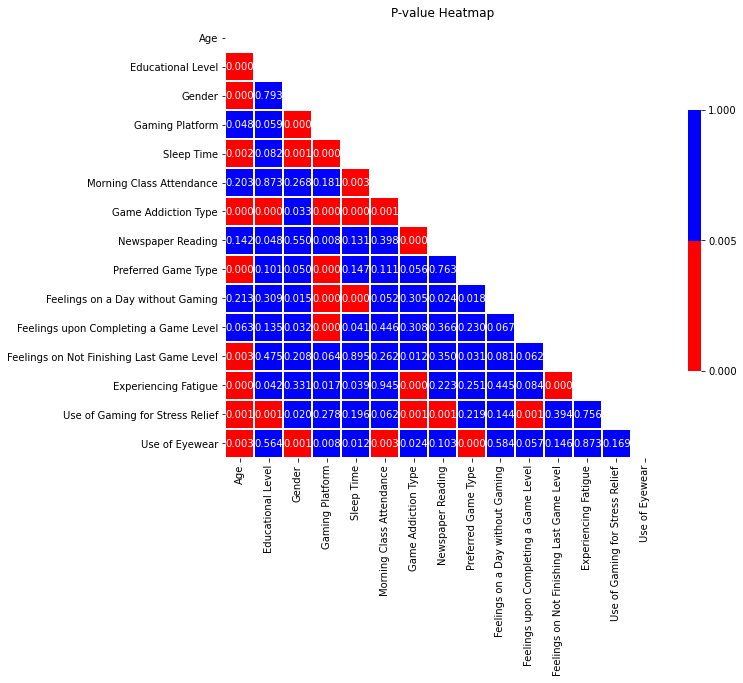

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import matplotlib.colors as mcolors

import pandas as pd 
df = pd.read_csv('igd_data.csv')

print(df.columns)
columns_to_drop = [df.columns[0], 
                   "Your  current CGPA?",
                   "Your Higher Secondary School(H. SC) or A level or equivalent result?",
                   "At what age you had started playing games?",
                   "The average time you spend playing games?",
                   "How many time you spend with family and friend?"]

# Drop the columns
df = df.drop(columns=columns_to_drop)
dfk = df
 
dfk.columns = [
    "Age", "Educational Level", "Gender", "Gaming Platform", "Sleep Time",
    "Morning Class Attendance", "Game Addiction Type", "Newspaper Reading",
    "Preferred Game Type", "Feelings on a Day without Gaming",
    "Feelings upon Completing a Game Level", "Feelings on Not Finishing Last Game Level",
    "Experiencing Fatigue", "Use of Gaming for Stress Relief", "Use of Eyewear"
]
p_values = pd.DataFrame(index=dfk.columns, columns=dfk.columns)

 
p_values = pd.DataFrame(index=dfk.columns, columns=dfk.columns)

for col1 in dfk.columns:
    for col2 in dfk.columns:
        if col1 != col2:
            crosstab = pd.crosstab(dfk[col1], dfk[col2])
            p_values.loc[col1, col2] = chi2_contingency(crosstab)[1]
        else:
            p_values.loc[col1, col2] = np.nan

# Plot the heatmap of p-values
fig = plt.figure(figsize=(15, 10))
# Generate a mask for the upper triangle
p_values.fillna(1, inplace=True)
mask = np.triu(np.ones_like(p_values, dtype=bool))
data_array = p_values

# Create a mask for the upper triangle  
mask = np.triu(np.ones_like(data_array, dtype=bool))

# Define a custom colormap: values less than or equal to 0.005 in red, otherwise blue
cmap = mcolors.ListedColormap(['red', 'blue'])
boundaries = [0, 0.005, 1]
norm = mcolors.BoundaryNorm(boundaries, cmap.N, clip=True)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data_array, mask=mask, annot=True, linewidths=.5,
            cbar_kws={"shrink": 0.6}, square=True,fmt=".3f",
            vmin=0, vmax=1,  # Assuming p-values range from 0 to 1
            cmap=cmap, norm=norm)

plt.title("P-value Heatmap")
# Save the full figure without cutting off parts
plt.savefig('pvalue.jpg', bbox_inches='tight')

plt.show()